## 🛠 Exercises

1. Write a function to visualize an image from any dataset (train or test file) and any class (e.g. "steak", "pizza"... etc), visualize it and make a prediction on it using a trained model.
2. Use feature-extraction to train a transfer learning model on 10% of the Food Vision data for 10 epochs using [`tf.keras.applications.efficientnet_v2.EfficientNetV2B0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet_v2/EfficientNetV2B0) as the base model. Use the [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback to save the weights to file.
3. Fine-tune the last 20 layers of the base model you trained in 2 for another 10 epochs. How did it go?
4. Fine-tune the last 30 layers of the base model you trained in 2 for another 10 epochs. How did it go?

## Import the right modules for tensorflow.keras

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
print(tf.__version__) # find the version number (should be 2.x+)
print(tf.config.list_physical_devices('GPU'))

version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
    import tf_keras as keras
else:
    keras = tf.keras

2025-05-19 20:00:52.818458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747695652.855860   75716 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747695652.867083   75716 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747695652.952996   75716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747695652.953033   75716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747695652.953039   75716 computation_placer.cc:177] computation placer alr

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load my own dataset: porous templates

### 1. Import and inspect data

In [2]:
import os

# Set images directory:
dir_images = "AAO_images/"

# Walk through the images directory and list number of files:
for dirpath, dirnames, filenames in os.walk(dir_images):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'AAO_images/'.
There are 4 directories and 0 images in 'AAO_images/test'.
There are 0 directories and 88 images in 'AAO_images/test/r4a7_PmenorIgual30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_Pmayor40'.
There are 0 directories and 39 images in 'AAO_images/test/r4a7_Pmayor30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_PmenorIgual40'.
There are 4 directories and 0 images in 'AAO_images/train'.
There are 0 directories and 354 images in 'AAO_images/train/r4a7_PmenorIgual30'.
There are 0 directories and 256 images in 'AAO_images/train/r12a15_Pmayor40'.
There are 0 directories and 159 images in 'AAO_images/train/r4a7_Pmayor30'.
There are 0 directories and 254 images in 'AAO_images/train/r12a15_PmenorIgual40'.


In [3]:
# Get the class names (programmatically, this is much more helpful with a longer list of classes)
import pathlib
import numpy as np

data_dir = pathlib.Path(dir_images+'train/') # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['r12a15_Pmayor40' 'r12a15_PmenorIgual40' 'r4a7_Pmayor30'
 'r4a7_PmenorIgual30']


In [4]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img,cmap='gray')
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (256, 256)


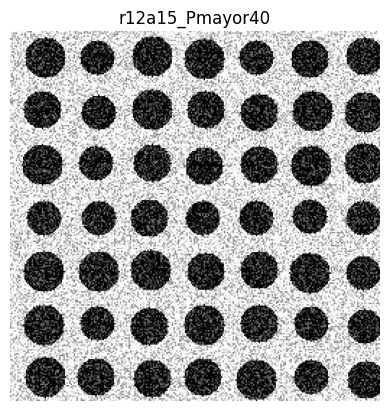

In [5]:
# View a random image from the training dataset
img = view_random_image(target_dir=dir_images+'train/',
                        target_class="r12a15_Pmayor40")

### 2. Preprocess the data

In [6]:
# Setup the train and test directories
train_dir = dir_images+"train/"
test_dir = dir_images+"test/"

# Create data inputs
IMG_SIZE = (256, 256) # define image size
train_data = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                 image_size=IMG_SIZE,
                                                                 color_mode='rgb', # Convert to 3 channels
                                                                 label_mode="categorical", # what type are the labels?
                                                                 batch_size=32) # batch_size is 32 by default, this is generally a good number
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                color_mode='rgb', # Convert to 3 channels
                                                                label_mode="categorical")

Found 1023 files belonging to 4 classes.


I0000 00:00:1747695715.570601   75716 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6251 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 257 files belonging to 4 classes.


### 3. Build a transfer learning model

In [18]:
INIT_EPOCHS = 10
IMG_SHAPE = (256, 256, 3)
N_CLASSES = len(class_names)

# 1. Create base model with tf.keras.applications
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

# 2. Freeze the base model (so the pre-learned patterns remain)
base_model.trainable = False

# 3. Create inputs into the base model
inputs = tf.keras.layers.Input(shape=IMG_SHAPE, name="input_layer")

# 4. Pass the inputs to the base_model (note: using tf.keras.applications, EfficientNetV2 inputs don't have to be normalized)
x = base_model(inputs)
# Check data shape after passing it to base_model
print(f"Shape after base_model: {x.shape}")

# 5. Average pool the outputs of the base model (aggregate all the most important information, reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"After GlobalAveragePooling2D(): {x.shape}")

# 6. Create the output activation layer
outputs = tf.keras.layers.Dense(N_CLASSES, activation="softmax", name="output_layer")(x)

# 7. Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs, outputs)

# 8. Compile the model
model_0.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# 9. Fit the model (we use less steps for validation so it's faster)
history_0 = model_0.fit(train_data,
                        epochs=INIT_EPOCHS,
                        # steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        # Go through less of the validation data so epochs are faster (we want faster experiments!)
                        validation_steps=int(0.5 * len(test_data)),
                        )

Shape after base_model: (None, 8, 8, 1280)
After GlobalAveragePooling2D(): (None, 1280)
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 295ms/step - accuracy: 0.5908 - loss: 0.9801 - val_accuracy: 0.8750 - val_loss: 0.3872
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8605 - loss: 0.3893 - val_accuracy: 0.9062 - val_loss: 0.2718
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9139 - loss: 0.2873 - val_accuracy: 1.0000 - val_loss: 0.0261
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9072 - loss: 0.2643 - val_accuracy: 0.9375 - val_loss: 0.1893
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9358 - loss: 0.2206 - val_accuracy: 0.9297 - val_loss: 0.1863
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9358 - loss: 0.2113 - val_accuracy: 1.0000 - val_loss: 0.0219
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9342 - loss: 0.1906 - val_accuracy: 0.9297 - val_loss: 0.1757
Epoch 8/10
32/32 ━━━━

In [19]:
model_0.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,934,686 (22.64 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 10,250 (40.04 KB)

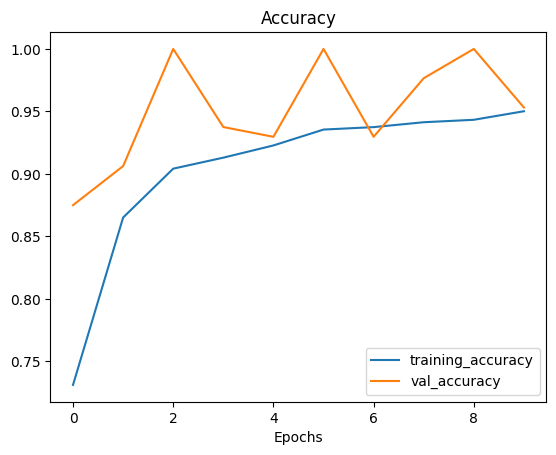

In [20]:
from helper_functions import plot_acc_curves

# Check out our model's training curves
plot_acc_curves(history_0)

### 4. Adding data augmentation right into the model

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip(),
  layers.RandomZoom(0.2),
], name ="data_augmentation")

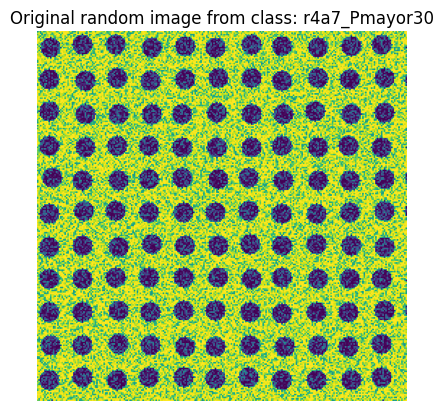

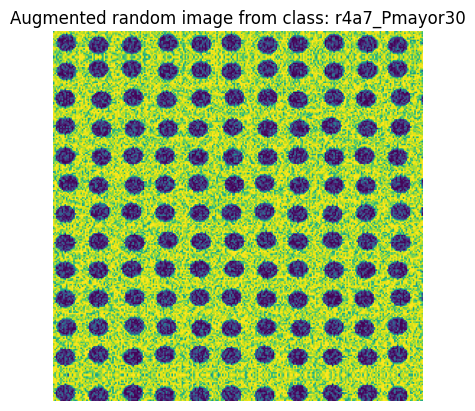

In [23]:
# View a random image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data.class_names) # choose a random class
target_dir = "AAO_images/train/" + target_class # create the target directory
random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
random_image_path = target_dir + "/" + random_image # create the choosen random image path
img = mpimg.imread(random_image_path) # read in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # turn off the axes

# Augment the image
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3)
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.) # requires normalization after augmentation
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False);

### 5. Build a model with augmented data:

In [24]:
# Setup input shape and base model, freezing the base model layers
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

data_augmentation = keras.Sequential([
  layers.RandomFlip(),
  layers.RandomZoom(0.2),
], name ="data_augmentation")

# Create input layer
inputs = layers.Input(shape=IMG_SHAPE, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(N_CLASSES, activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model_1 = keras.Model(inputs, outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=INIT_EPOCHS,
                        # steps_per_epoch=len(train_data_1_percent),
                        validation_data=test_data,
                        validation_steps=int(0.5* len(test_data)), # validate for less steps
                        )

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.5870 - loss: 1.1035 - val_accuracy: 0.8359 - val_loss: 0.4450
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8674 - loss: 0.4505 - val_accuracy: 0.8594 - val_loss: 0.3642
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9027 - loss: 0.3244 - val_accuracy: 1.0000 - val_loss: 0.0412
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9052 - loss: 0.3003 - val_accuracy: 0.8750 - val_loss: 0.2703
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8938 - loss: 0.2861 - val_accuracy: 0.8750 - val_loss: 0.2475
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9083 - loss: 0.2467 - val_accuracy: 1.0000 - val_loss: 0.4417
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9112 - loss: 0.2331 - val_accuracy: 0.9297 - val_loss: 0.2250
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9354 - loss: 0.2064 - val_accuracy: 0.9688 -

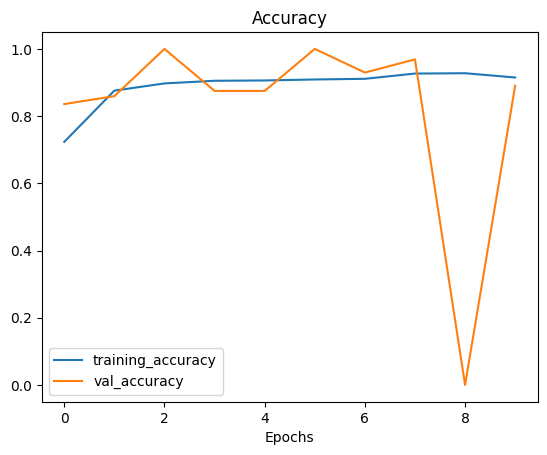

In [25]:
# Check out our model's training curves
plot_acc_curves(history_1)

### 6. Fine-tune an existing model:

In [32]:
def create_base_model(input_shape: tuple[int, int, int] = IMG_SHAPE,
                      output_shape: int = N_CLASSES,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:
    """
    Create a model based on EfficientNetV2B0 with built-in data augmentation.

    Parameters:
    - input_shape (tuple): Expected shape of input images. Default is (224, 224, 3).
    - output_shape (int): Number of classes for the output layer. Default is 10.
    - learning_rate (float): Learning rate for the Adam optimizer. Default is 0.001.
    - training (bool): Whether the base model is trainable. Default is False.

    Returns:
    - tf.keras.Model: The compiled model with specified input and output settings.
    """
    # Create base model
    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training

    # Setup model input and outputs with data augmentation built-in
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # pass augmented images to base model but keep it in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)

    # Compile model
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model

# Create an instance of model_2 with our new function
model_2 = create_base_model()

In [33]:
# # Setup checkpoint path
checkpoint_path = "AAO_model_checkpoints_weights/checkpoint.weights.h5" # note: remember saving directly to Colab is temporary

# # Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

In [34]:
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=data_augmentation, built=True>,
 <Functional name=efficientnetv2-b0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling_layer, built=True>,
 <Dense name=output_layer, built=True>]

In [35]:
# Access the base_model layers of model_2
model_2_base_model = model_2.layers[2]
model_2_base_model.name

'efficientnetv2-b0'

In [36]:
# How many layers are trainable in our model_2_base_model?
print(len(model_2_base_model.trainable_variables)) # layer at index 2 is the EfficientNetV2B0 layer (the base model)

0


In [40]:
# Fit the model saving checkpoints every epoch
history_2_frozen = model_2.fit(train_data,
                               epochs=INIT_EPOCHS,
                               validation_data=test_data,
                               validation_steps=int(0.5 * len(test_data)), # do less steps per validation (quicker)
                               callbacks=[checkpoint_callback])

Epoch 1/10


E0000 00:00:1747697120.853353   75716 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4445 - loss: 1.2130
Epoch 1: val_loss improved from inf to 0.74501, saving model to AAO_model_checkpoints_weights/checkpoint.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.4496 - loss: 1.2064 - val_accuracy: 0.8359 - val_loss: 0.7450
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8302 - loss: 0.5748
Epoch 2: val_loss improved from 0.74501 to 0.41621, saving model to AAO_model_checkpoints_weights/checkpoint.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8307 - loss: 0.5734 - val_accuracy: 0.9375 - val_loss: 0.4162
Epoch 3/10
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8717 - loss: 0.4129
Epoch 3: val_loss did not improve from 0.41621
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8729 - loss: 0.4111 - val_accuracy: 1.0000 - val_loss: 0.5882
Epoch 4/10
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8966 - loss: 0.3503
Epoch 4: val_loss improved from 0.41621

In [41]:
# Evaluate on the test data
results_2_frozen = model_2.evaluate(test_data)
results_2_frozen

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9435 - loss: 0.1751


[0.179012268781662, 0.9377431869506836]

In [43]:
# # Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)
loaded_weights_model_results

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9329 - loss: 0.2226


[0.19750918447971344, 0.9494163393974304]

In [44]:
# Make all the layers in model_2_base_model trainable
model_2_base_model.trainable = True

# Freeze all layers except for the last 10
for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False

# Recompile the whole model (always recompile after any adjustments to a model)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])

# How many layers are trainable in our model_2_base_model?
print(len(model_2_base_model.trainable_variables)) # layer at index 2 is the EfficientNetV2B0 layer (the base model)

10


In [45]:
print(len(model_2.trainable_variables))

12


In [46]:
# Fine tune for another 5 epochs
FINE_EPOCHS = 10
fine_tune_epochs = INIT_EPOCHS + FINE_EPOCHS

# Refit the model (same as model_2 except with more trainable layers)
history_2_fine = model_2.fit(train_data,
                             epochs=fine_tune_epochs,
                             validation_data=test_data,
                             initial_epoch=history_2_frozen.epoch[-1], # start from previous last epoch
                             validation_steps=int(0.5 * len(test_data))) 

Epoch 10/20


E0000 00:00:1747697256.298470   75716 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9155 - loss: 0.2555 - val_accuracy: 0.9297 - val_loss: 0.2226
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9136 - loss: 0.2420 - val_accuracy: 0.9375 - val_loss: 0.1612
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9135 - loss: 0.2228 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9234 - loss: 0.1965 - val_accuracy: 0.9375 - val_loss: 0.1535
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9328 - loss: 0.1938 - val_accuracy: 0.9531 - val_loss: 0.1771
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9286 - loss: 0.1866 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9467 - loss: 0.1834 - val_accuracy: 0.9688 - val_loss: 0.1366
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9344 - loss: 0.1697 - val_accuracy: 1.0000 - val_l

In [47]:
# Evaluate the model on the test data
results_2_fine = model_2.evaluate(test_data)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9697 - loss: 0.1004


In [48]:
def compare_historys(original_history, new_history, initial_epochs=INIT_EPOCHS):
    """
    Compares two model history objects.
    """
    # Get original history measurements
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    # Combine original history with new history
    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()

10
21
[0.6148582696914673, 0.8465298414230347, 0.890518069267273, 0.900293231010437, 0.8983381986618042, 0.8963831663131714, 0.9110459685325623, 0.9159335494041443, 0.9305962920188904, 0.9149560332298279, 0.9120234847068787, 0.9178885817527771, 0.9178885817527771, 0.9208211302757263, 0.9217986464500427, 0.9257087111473083, 0.9217986464500427, 0.9384164214134216, 0.934506356716156, 0.9403714537620544, 0.9364613890647888]


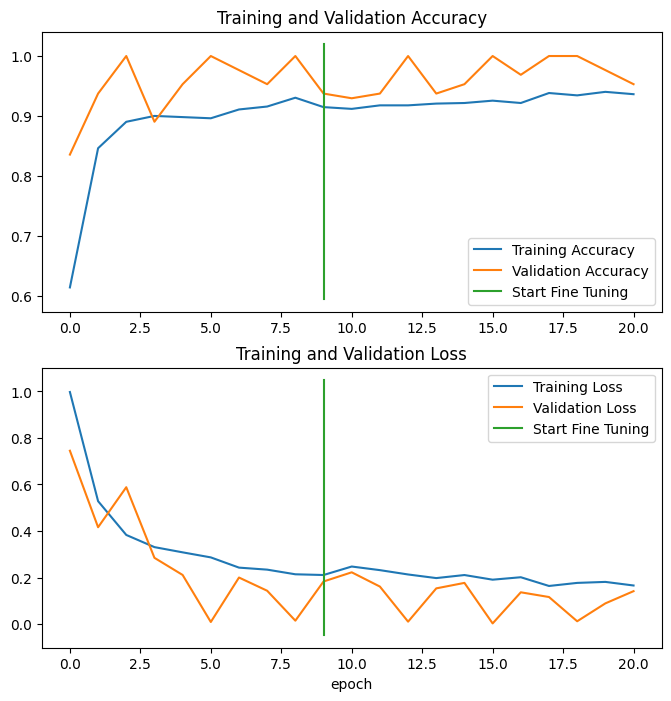

In [49]:
compare_historys(original_history=history_2_frozen,
                 new_history=history_2_fine,
                 initial_epochs=INIT_EPOCHS)

## 📖 Extra-curriculum

* Read the [documentation on data augmentation](https://www.tensorflow.org/tutorials/images/data_augmentation) in TensorFlow.
* Read the [ULMFit paper](https://arxiv.org/abs/1801.06146) (technical) for an introduction to the concept of freezing and unfreezing different layers.
* Read up on learning rate scheduling (there's a [TensorFlow callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/LearningRateScheduler) for this), how could this influence our model training?
  * If you're training for longer, you probably want to reduce the learning rate as you go... the closer you get to the bottom of the hill, the smaller steps you want to take. Imagine it like finding a coin at the bottom of your couch. In the beginning your arm movements are going to be large and the closer you get, the smaller your movements become.